<a href="https://colab.research.google.com/github/jorge-reynam/Car_Sales_Dashboard-Streamlit_Web_App/blob/main/Reporte_de_usuarios_SECTEI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar las librerías para trabajar

In [13]:
#Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargar los datos de Google Sheets

In [14]:
#Hacer una función que lea la hoja de Google Sheets

def read_google_sheet(url, sheet_name):
    try:
        sheet_id = url.split("/d/")[1].split("/")[0]
        csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
        df = pd.read_csv(csv_url)
        return df
    except Exception as e:
        print(f"Error al leer la hoja: {e}")
        return None


In [109]:
#Leer los datos desde el Google Sheets

url = "https://docs.google.com/spreadsheets/d/11UO33BWLkyARPpsn0QU7EdiaLitfsuN2/edit?usp=sharing&ouid=116787326570682110375&rtpof=true&sd=true"

df_PILARES = read_google_sheet(url, "Atenciones")

In [98]:
#Función que devuelve las atenciones diarias

def daily_appointments(df):
  # Crear una copia del DataFrame para evitar modificar el original
  df_processed = df.copy()

  # Convertir los strings a formato fecha
  df_processed['Fecha'] = df_processed['Fecha'].apply(lambda x: pd.to_datetime(x, format='%Y-%m-%d'))

  #Filtrar solo datos de 2025
  df_processed = df_processed[(df_processed['Fecha'] >= '2025-01-01') & (df_processed['Fecha'] <= '2025-12-31')]

  # Agrupar los datos por día
  daily_appointments_2025 = df_processed.groupby('Fecha').size()

  #Graficar los folios por día
  plt.figure(figsize=(15, 6))
  sns.barplot(x=daily_appointments_2025.index, y=daily_appointments_2025.values, color='#8b0000')
  plt.title('Atenciones Diarias (2025)')
  plt.xlabel('Fecha')
  plt.ylabel('Número de atenciones')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()


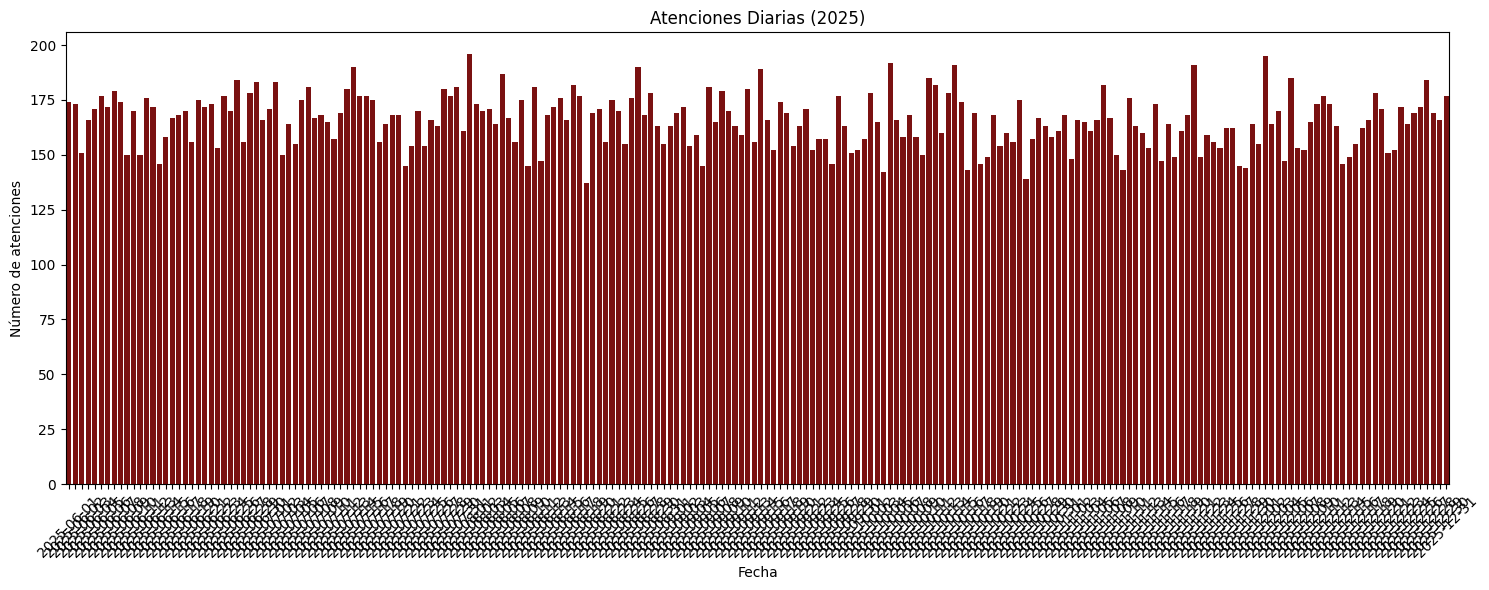

In [99]:
daily_appointments(df_PILARES)

In [106]:
#Función que devuelve las atenciones por mes

def monthly_appointments(df):
  # Crear una copia del DataFrame para evitar modificar el original
  df_processed = df.copy()

  # Convertir los strings a formato fecha si no lo están ya
  if not pd.api.types.is_datetime64_any_dtype(df_processed['Fecha']):
    df_processed['Fecha'] = df_processed['Fecha'].apply(lambda x: pd.to_datetime(x, format='%Y-%m-%d'))

  #Filtrar solo datos de 2025
  df_processed = df_processed[(df_processed['Fecha'] >= '2025-01-01') & (df_processed['Fecha'] <= '2025-12-31')]

  #Agrupar las atenciones por mes
  monthly_appointments_df = df_processed.groupby(pd.Grouper(key='Fecha', freq='ME')).size()

  #Graficar los folios por día
  plt.figure(figsize=(10, 5))
  sns.barplot(x=monthly_appointments_df.index.strftime('%Y-%m'), y=monthly_appointments_df.values, color='#8b0000')
  plt.title('Atenciones mensuales')
  plt.xlabel('Fecha')
  plt.ylabel('Número de atenciones')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()


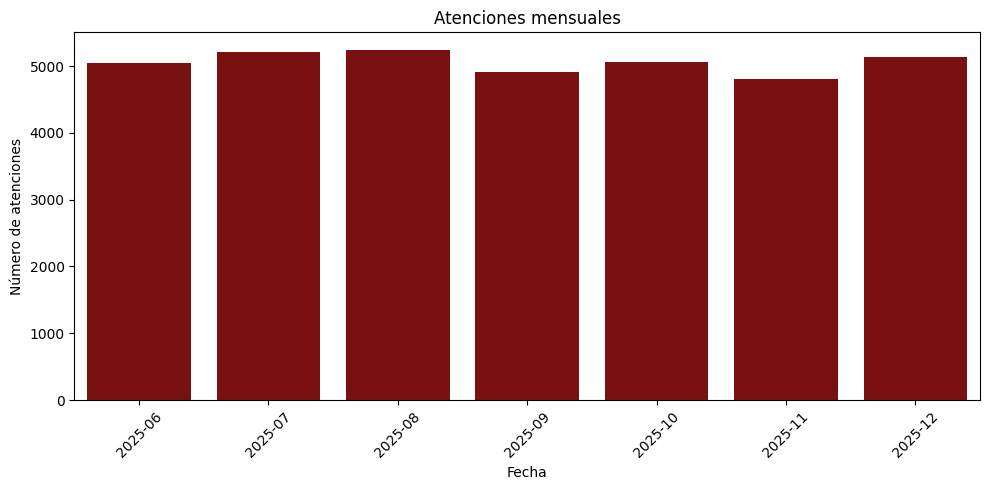

In [107]:
monthly_appointments(df_PILARES)